In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

meta = unpickle('../dataset_big/cifar-10-batches-py/batches.meta')
# conver meta in a list of strings
label_names = [label.decode('utf-8') for label in meta[b'label_names']]
label_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

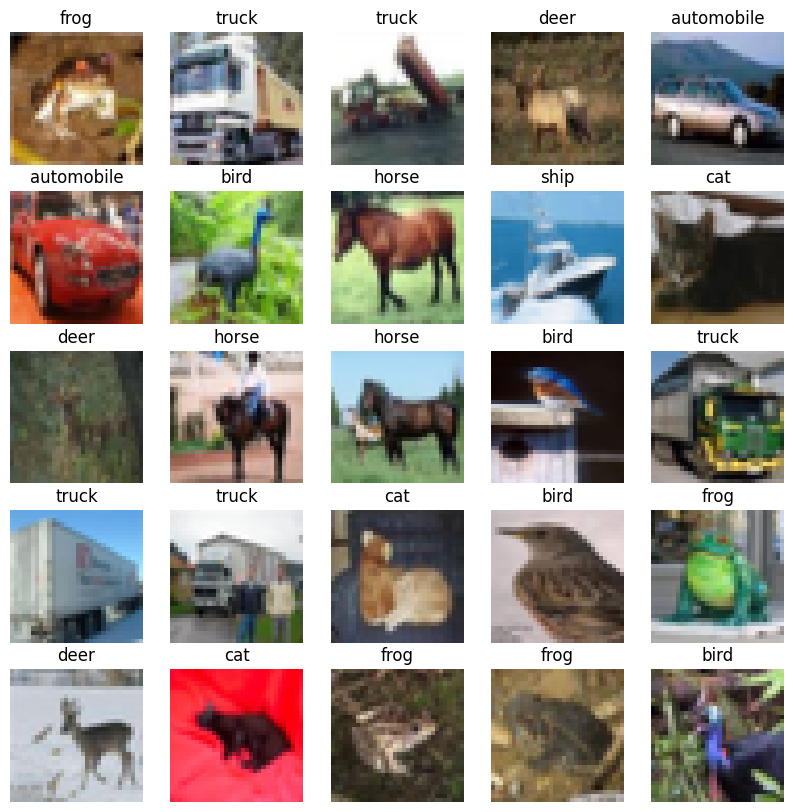

In [9]:


# load all the 5 data batches
# each batch contains 10000 images
# put them together in a single dataset
data_list = []  
for i in range(1,6):
    batch = unpickle(f'../dataset_big/cifar-10-batches-py/data_batch_{i}')
    data_list.append(batch[b'data'])
data = np.vstack(data_list)
labels = []
for i in range(1,6):
    batch = unpickle(f'../dataset_big/cifar-10-batches-py/data_batch_{i}')
    labels.extend(batch[b'labels']) 


# plot a grid of 5 X 5 images
plt.figure(figsize=(10,10)) 
for i in range(25):
    img = data[i]
    img = img.reshape(3, 32, 32).transpose(1, 2, 0)
    plt.subplot(5,5,i+1)
    plt.title(label_names[labels[i]])
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [4]:
data.shape

(50000, 3072)

In [11]:
len(labels)

50000

In [15]:
# https://keras.io/getting_started/intro_to_keras_for_engineers/

# 32 * 32 * 3 = 3072

# Scale images to the [0, 1] range
x_train = data.astype("float32") / 255
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")

x_train shape: (50000, 3072)
50000 train samples


In [16]:
num_classes = 10
input_shape = (32, 32, 3)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,450 (1021.29 KB)

 Trainable params: 261,450 (1021.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
y_train = np.array(labels)
x_train = x_train.reshape(x_train.shape[0], 32,32,3)

print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000,)


In [22]:

callbacks = [
    #keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2),
]
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2, callbacks=callbacks)


Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - loss: 1.9589 - val_loss: 1.7542
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - loss: 1.7090 - val_loss: 1.5440
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 1.5721 - val_loss: 1.4692
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 1.4724 - val_loss: 1.3664
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - loss: 1.3930 - val_loss: 1.2971
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 1.3207 - val_loss: 1.2680
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - loss: 1.2642 - val_loss: 1.2275
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - loss: 1.2157 - val_loss: 1.2253
Epoch 9/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - loss: 1.1712 - val_loss: 1.1740
Epoch 10/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 73s 59ms/step - loss: 1.1323 - val_loss: 1.1244
Epoch 11/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - loss: 1.0923 - val_loss: 1.1116
Epoch 12

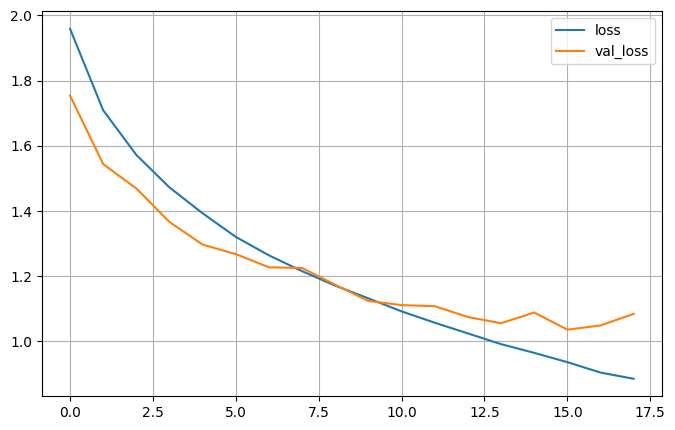

In [32]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [24]:
model.save('saved_cifar10CONV.keras')

In [12]:
model = keras.saving.load_model("saved_cifar10CONV.keras")

ValueError: File not found: filepath=saved_cifar10CONV.keras. Please ensure the file is an accessible `.keras` zip file.

In [42]:
# load test batch
test_batch = unpickle('../dataset_big/cifar-10-batches-py/test_batch')
x_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])
x_test = x_test.astype("float32") / 255
x_test = x_test.reshape(x_test.shape[0], 32,32,3)
print(x_test.shape)
print(y_test.shape)

(10000, 32, 32, 3)
(10000,)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


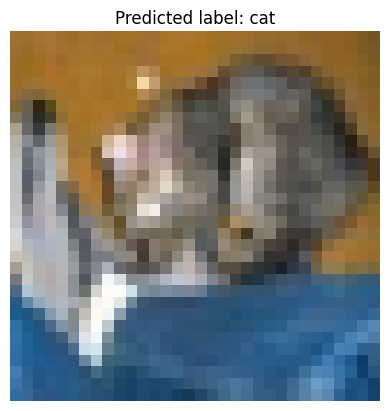

In [65]:
# try predicting the first image in the training set
predictions = model.predict(x_test[0:1])
predictions[:2]
cpredictions = [np.argmax(p) for p in predictions]
cpredictions
img = x_test[0]
img = img.reshape(3, 32, 32).transpose(1, 2, 0)
plt.imshow(img)
plt.title(f'Predicted label: {label_names[cpredictions[0]]}')
plt.axis('off')
plt.show()

In [71]:
# predict all test images
predictions = model.predict(x_test)
cpredictions = [np.argmax(p) for p in predictions]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


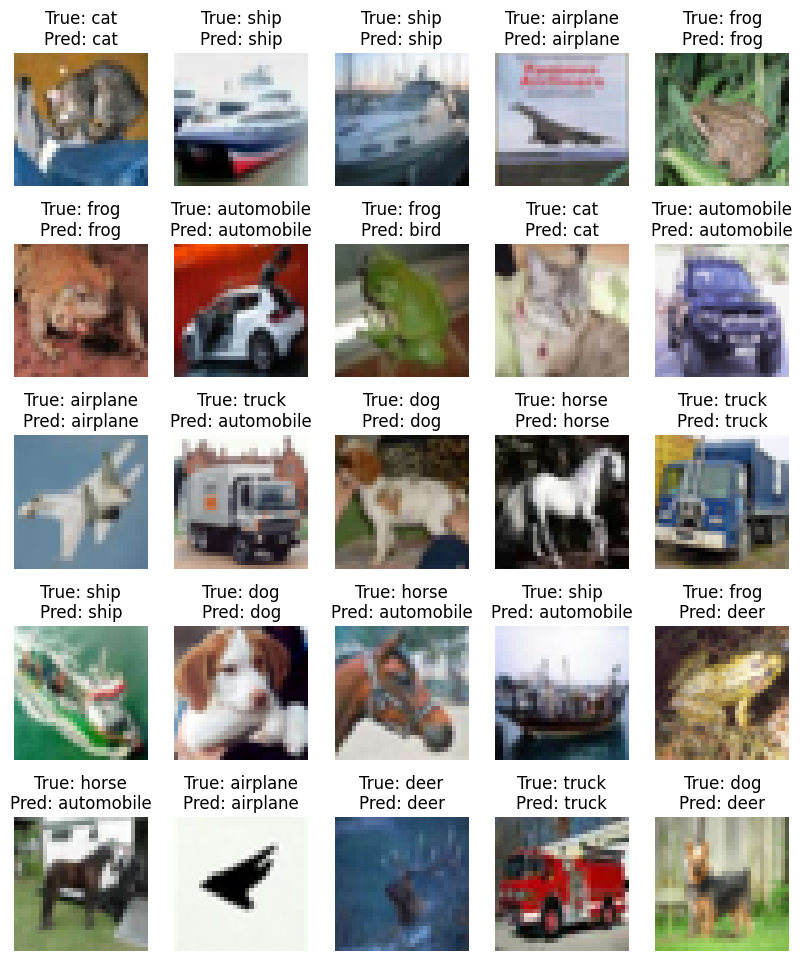

In [73]:
#create a grid of 5 X 5 images with predictions and true labels
plt.figure(figsize=(10,12))
for i in range(25):
    img = x_test[i]
    img = img.reshape(3, 32, 32).transpose(1, 2, 0)
    plt.subplot(5,5,i+1)
    plt.title(f'True: {label_names[y_test[i]]}\nPred: {label_names[cpredictions[i]]}')
    plt.imshow(img)
    plt.axis('off')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


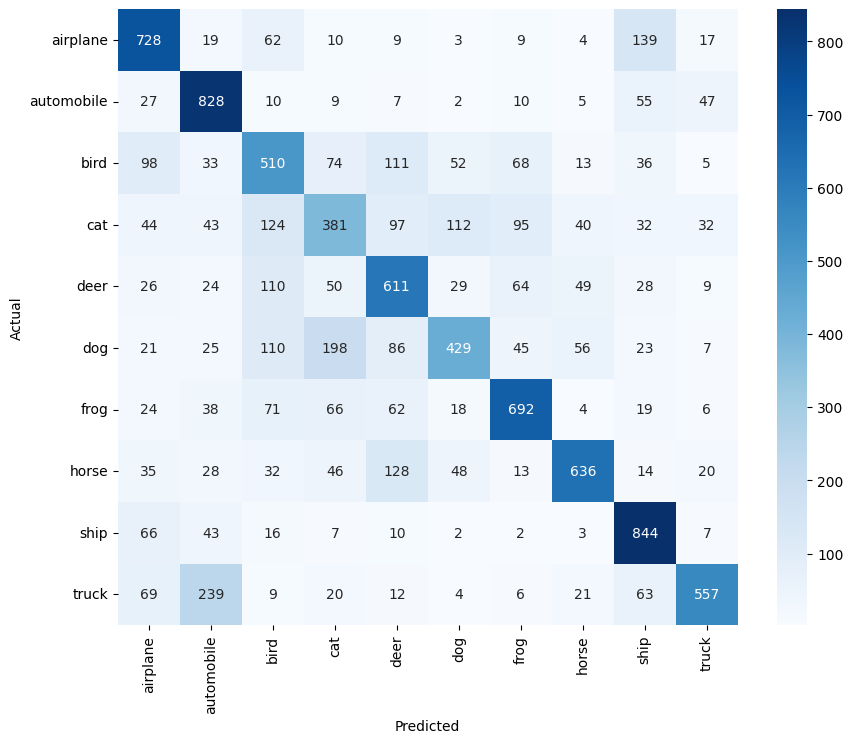

In [75]:
# print confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, cpredictions)
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()